# Aula 06 Hands-On — Atenção e Transformer Encoder em Reviews em Português

## Contexto
Nesta prática comparamos duas hipóteses de modelagem para classificação textual: um baseline lexical baseado em TF-IDF e um mini-Transformer encoder treinado do zero. O dataset é sintético, mas construído de propósito para que **a ordem e o contexto importem**. A tarefa é dizer **qual aspecto da compra motivou a reclamação** — entrega, qualidade ou atendimento — ou reconhecer que a review é um elogio.

O ponto central do desenho é este: todas as classes compartilham o mesmo vocabulário de julgamentos (`decepcionou`, `surpreendeu`, `falhou feio`, `funcionou direito`...) e o que liga um julgamento ao aspecto certo é **posição, escopo e ordem**, nunca a presença isolada de uma palavra. Um modelo de sacola-de-palavras vê o conjunto `{entrega, acabamento, surpreendeu, decepcionou}` idêntico em duas reviews de classes opostas.

## Objetivos de aprendizagem
- Construir um corpus sintético em português no qual a decisão dependa de negação com escopo, inversão adversativa e dependência de longa distância.
- Comparar dois baselines lexicais (TF-IDF só com unigramas e TF-IDF com 1–2 gramas) com um encoder baseado em autoatenção.
- Medir desempenho com acurácia, macro-F1 e log loss, e quebrar o resultado **por tipo de construção linguística**.
- Visualizar pesos de atenção como instrumento diagnóstico, sem tratá-los como explicação final.

## Pergunta experimental e hipótese
**Pergunta:** quando a classe depende de *qual* aspecto foi criticado — e não de *quais palavras* aparecem —, um encoder com autoatenção supera um baseline bag-of-words? E adicionar bigramas ao TF-IDF é suficiente para fechar a diferença?

**Hipótese:**
- Nas frases **diretas** (um aspecto, um julgamento) os dois modelos devem acertar quase tudo: aí o vocabulário basta.
- Nas frases **adversativas** (`X foi ótimo, mas Y decepcionou`) o TF-IDF deve cair para perto de 50%, porque a sacola de palavras é idêntica quando trocamos X por Y.
- Nas frases com **negação de escopo** (`não dá pra dizer que ... decepcionou` = elogio) o TF-IDF precisaria representar uma interação (negação × polaridade do julgamento) que uma regressão logística linear sobre contagens não consegue formar.
- Nas frases com **anáfora ordinal** (`comparando A ... e B ..., só o segundo decepcionou`) só ajuda quem consegue relacionar posições distantes.
- **Bigramas não devem resolver**, porque os fillers inseridos garantem que aspecto e julgamento nunca fiquem a menos de dois tokens de distância — o remendo local não alcança a dependência.
- Nas frases **ambíguas** (duas críticas coordenadas) **ninguém** deve passar de ~50%: o rótulo não está determinado pelo texto. Esse é o teto de Bayes do experimento.
- O **mini-Transformer deve ficar vários pontos acima**, e nenhum dos modelos deve saturar em 100%: se saturar, o experimento não distingue as hipóteses.
- Rodamos o encoder com **uma e com duas camadas**, mantendo todo o resto igual. A previsão é que uma camada já resolva a adversativa e a anáfora ordinal — que pedem ligar duas posições —, mas **tropece na negação de escopo**, que exige compor duas informações em etapas sucessivas ("há negação?" e "o julgamento é positivo ou negativo?").

## Setup, imports e semente de reprodutibilidade
O notebook usa `sklearn` para os baselines e `PyTorch` para o mini-Transformer. Como o foco é arquitetura e não pré-treinamento, todo o pipeline de tokenização é mantido explícito.

In [1]:
import math
import random
from collections import Counter
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.style.use('seaborn-v0_8-whitegrid')
device

'cuda'

## Geração do dataset textual
O corpus é montado com cinco construções, todas usando o **mesmo vocabulário de aspectos e de julgamentos**:

| construção | exemplo | por que é difícil para bag-of-words |
|---|---|---|
| **direta** | `chat pra mim estragou a compra` | não é difícil — é o piso comum aos dois modelos |
| **adversativa** | `em geral, frete, na prática, surpreendeu, mas dessa vez, bateria, de verdade, decepcionou` | a sacola de palavras é **idêntica** se trocarmos qual aspecto recebeu o elogio e qual recebeu a crítica |
| **negação de escopo** | `seria exagero afirmar que prazo dessa vez funcionou direito` (= reclamação de entrega) contra `não dá pra dizer que suporte até agora decepcionou` (= elogio) | a classe depende do **XOR** entre "há negação" e "o julgamento é positivo ou negativo"; uma regressão logística linear sobre contagens não forma esse produto |
| **anáfora ordinal** | `comparando pra mim, entrega, em geral, e no fim das contas, material, na prática, só o segundo falhou feio` | é preciso ligar `o segundo` ao aspecto que apareceu **em segundo lugar**, a muitos tokens de distância |
| **ambígua** (10% das reclamações) | `em geral, frete, pra mim, decepcionou, e dessa vez, bateria, na prática, falhou feio` | duas críticas coordenadas por `e`: o texto **não diz** qual foi a principal. O rótulo é um dos dois aspectos, sorteado |

A construção **ambígua** é proposital e não é ruído: ela cria um **erro de Bayes** de cerca de 4 pontos percentuais. Nenhum modelo — nem o melhor Transformer — pode passar desse teto, porque a informação simplesmente não está no texto. É o antídoto contra a leitura ingênua de que "acurácia alta o bastante resolve": parte do erro é do problema, não do modelo.

Dois cuidados tornam o experimento honesto:

1. **Fillers obrigatórios** (`de verdade`, `no dia a dia`, `dessa vez`, ...) são inseridos **antes e depois de cada aspecto**. Isso garante que nenhum n-grama de tamanho 1 ou 2 consiga ligar o aspecto ao seu julgamento — nem à conjunção adversativa. Sem esse cuidado, o TF-IDF com bigramas resolveria a tarefa com o atalho `mas entrega`.
2. **Negação equilibrada**: `não`/`ninguém`/`exagero` aparecem tanto em elogios quanto em reclamações. A palavra de negação sozinha é inútil — o que importa é sobre o que ela incide.

In [2]:
label_names = ['elogio', 'entrega', 'qualidade', 'atendimento']

ASPECTS = {
    1: ['entrega', 'prazo', 'rastreio', 'transportadora', 'frete'],
    2: ['acabamento', 'bateria', 'material', 'desempenho', 'durabilidade'],
    3: ['suporte', 'atendimento', 'chat', 'assistência', 'garantia'],
}
POSITIVE_VERDICTS = ['surpreendeu', 'funcionou direito', 'resolveu numa boa', 'agradou bastante', 'salvou a compra']
NEGATIVE_VERDICTS = ['decepcionou', 'falhou feio', 'complicou tudo', 'irritou demais', 'estragou a compra']
FILLERS = ['de verdade', 'até agora', 'no dia a dia', 'em geral', 'dessa vez',
           'pra mim', 'no fim das contas', 'na prática', 'sem exagero', 'depois de duas semanas']
NEGATION_PREFIX = ['não dá pra dizer que', 'ninguém aqui vai dizer que', 'seria exagero afirmar que']
AFFIRMATIVE_PREFIX = ['dá pra dizer que', 'todo mundo aqui vai dizer que', 'é justo afirmar que']
PRODUCTS = ['fone', 'notebook', 'cafeteira', 'aspirador', 'monitor', 'teclado']
OPENERS = ['comprei um {p} e', 'usei o {p} por um mês e', 'sobre o {p}:', 'segunda compra do {p} e', '']

CONSTRUCTIONS = ['direta', 'adversativa', 'negacao', 'ordinal', 'ambigua']
MIX_ELOGIO = [0.30, 0.30, 0.20, 0.20, 0.00]      # 'ambigua' so existe para reclamacoes
MIX_RECLAMACAO = [0.27, 0.27, 0.18, 0.18, 0.10]
N_PER_CLASS = 800


def make_review(label, rng):
    """Gera uma review e devolve tambem qual construcao foi usada, para a analise de erro."""
    construction = rng.choice(CONSTRUCTIONS, p=MIX_ELOGIO if label == 0 else MIX_RECLAMACAO)
    opener = rng.choice(OPENERS).replace('{p}', rng.choice(PRODUCTS))
    fill = list(rng.choice(FILLERS, size=4, replace=False))
    pos, neg = rng.choice(POSITIVE_VERDICTS), rng.choice(NEGATIVE_VERDICTS)

    if construction == 'direta':
        if label == 0:
            aspect = rng.choice(ASPECTS[rng.choice([1, 2, 3])])
            body = f'{aspect} {fill[0]} {pos}'
        else:
            aspect = rng.choice(ASPECTS[label])
            body = f'{aspect} {fill[0]} {neg}'

    elif construction == 'adversativa':
        if label == 0:
            c1, c2 = rng.choice([1, 2, 3], size=2, replace=False)
            a1, a2 = rng.choice(ASPECTS[c1]), rng.choice(ASPECTS[c2])
            other_pos = rng.choice(POSITIVE_VERDICTS)
            body = (f'{fill[0]}, {a1}, {fill[1]}, {pos}, '
                    f'e {fill[2]}, {a2}, {fill[3]}, {other_pos}')
        else:
            other = rng.choice([c for c in (1, 2, 3) if c != label])
            criticized, praised = rng.choice(ASPECTS[label]), rng.choice(ASPECTS[other])
            if rng.random() < 0.5:
                body = (f'{fill[0]}, {praised}, {fill[1]}, {pos}, '
                        f'mas {fill[2]}, {criticized}, {fill[3]}, {neg}')
            else:
                body = (f'{fill[0]}, {criticized}, {fill[1]}, {neg}, '
                        f'embora {fill[2]}, {praised}, {fill[3]}, {pos}')

    elif construction == 'negacao':
        negated = rng.random() < 0.5
        prefix = rng.choice(NEGATION_PREFIX) if negated else rng.choice(AFFIRMATIVE_PREFIX)
        if label == 0:
            aspect = rng.choice(ASPECTS[rng.choice([1, 2, 3])])
            verdict = neg if negated else pos          # negar algo ruim, ou afirmar algo bom
        else:
            aspect = rng.choice(ASPECTS[label])
            verdict = pos if negated else neg          # negar algo bom, ou afirmar algo ruim
        body = f'{prefix} {aspect} {fill[0]} {verdict}'

    elif construction == 'ambigua':
        # Duas criticas coordenadas por 'e': o texto NAO diz qual delas foi a principal.
        # O rotulo e um dos dois aspectos, sorteado — ou seja, existe um piso de erro
        # (erro de Bayes) que nenhum modelo consegue eliminar.
        other = rng.choice([c for c in (1, 2, 3) if c != label])
        mine, theirs = rng.choice(ASPECTS[label]), rng.choice(ASPECTS[other])
        other_neg = rng.choice(NEGATIVE_VERDICTS)
        if rng.random() < 0.5:
            body = f'{fill[0]}, {mine}, {fill[1]}, {neg}, e {fill[2]}, {theirs}, {fill[3]}, {other_neg}'
        else:
            body = f'{fill[0]}, {theirs}, {fill[1]}, {other_neg}, e {fill[2]}, {mine}, {fill[3]}, {neg}'

    else:  # anafora ordinal
        c1, c2 = rng.choice([1, 2, 3], size=2, replace=False)
        if label == 0:
            a1, a2 = rng.choice(ASPECTS[c1]), rng.choice(ASPECTS[c2])
            body = (f'comparando {fill[0]}, {a1}, {fill[1]}, e {fill[2]}, {a2}, {fill[3]}, '
                    f'nem o primeiro nem o segundo {neg}')
        else:
            other = rng.choice([c for c in (1, 2, 3) if c != label])
            criticized, praised = rng.choice(ASPECTS[label]), rng.choice(ASPECTS[other])
            if rng.random() < 0.5:
                body = (f'comparando {fill[0]}, {criticized}, {fill[1]}, e {fill[2]}, {praised}, {fill[3]}, '
                        f'só o primeiro {neg}')
            else:
                body = (f'comparando {fill[0]}, {praised}, {fill[1]}, e {fill[2]}, {criticized}, {fill[3]}, '
                        f'só o segundo {neg}')

    text = ' '.join(f'{opener} {body}.'.strip().split()).lower()
    return text, construction


rng = np.random.default_rng(SEED)
rows = []
for label in range(len(label_names)):
    for _ in range(N_PER_CLASS):
        text, construction = make_review(label, rng)
        rows.append({'text': text, 'label': label, 'construcao': construction})

df = pd.DataFrame(rows)
train_df, temp_df = train_test_split(df, test_size=0.4, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

ambiguous_share = float((df['construcao'] == 'ambigua').mean())
print(f'corpus: {len(df)} reviews | treino {len(train_df)} | validação {len(val_df)} | teste {len(test_df)}')
print(f'reviews duplicadas: {1 - df["text"].nunique() / len(df):.2%}')
print(f'fração ambígua: {ambiguous_share:.1%} -> teto teórico de acurácia (erro de Bayes): '
      f'{1 - ambiguous_share / 2:.3f}')
print(df.groupby('construcao').size().to_string())
print()
for construction in CONSTRUCTIONS:
    sample = df[df['construcao'] == construction].sample(1, random_state=SEED).iloc[0]
    print(f'[{construction} -> {label_names[sample["label"]]}] {sample["text"]}')
df.sample(5, random_state=SEED)

corpus: 3200 reviews | treino 1920 | validação 640 | teste 640
reviews duplicadas: 0.41%
fração ambígua: 7.2% -> teto teórico de acurácia (erro de Bayes): 0.964
construcao
adversativa    933
ambigua        229
direta         835
negacao        574
ordinal        629

[direta -> qualidade] desempenho no dia a dia estragou a compra.
[adversativa -> atendimento] segunda compra do fone e no dia a dia, atendimento, até agora, irritou demais, embora no fim das contas, frete, na prática, agradou bastante.
[negacao -> atendimento] segunda compra do fone e é justo afirmar que suporte até agora irritou demais.
[ordinal -> atendimento] usei o cafeteira por um mês e comparando dessa vez, chat, em geral, e no fim das contas, durabilidade, no dia a dia, só o primeiro falhou feio.
[ambigua -> atendimento] sobre o teclado: no dia a dia, atendimento, pra mim, estragou a compra, e em geral, transportadora, sem exagero, falhou feio.


,text,label,construcao
2384,"sobre o teclado: de verdade, durabilidade, no ...",2,adversativa
2538,segunda compra do monitor e garantia na prátic...,3,direta
2176,"sobre o teclado: na prática, entrega, em geral...",2,adversativa
897,segunda compra do aspirador e comparando na pr...,1,ordinal
214,"comparando depois de duas semanas, material, n...",0,ordinal


## Baselines e por que eles importam
O baseline TF-IDF + regressão logística continua sendo obrigatório em NLP aplicado porque costuma ser barato, estável e surpreendentemente forte. Se o Transformer não superar esse baseline, a conclusão prática é que a complexidade adicional ainda não se pagou neste regime de dados.

Aqui rodamos **duas versões** do baseline, e a comparação entre elas já é um resultado por si só:

- **TF-IDF unigramas** — a sacola de palavras clássica, que ignora completamente a ordem;
- **TF-IDF 1–2 gramas** — o remendo mais comum para recuperar um pouco de ordem local.

Se os bigramas não melhorarem, é evidência de que a dependência que a tarefa exige é **mais longa que dois tokens** — e portanto fora do alcance de qualquer janela fixa pequena.

In [3]:
baseline_configs = {
    'TF-IDF unigramas + LR': (1, 1),
    'TF-IDF 1-2 gramas + LR': (1, 2),
}


def evaluate_baseline(ngram_range, train_df, test_df):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=2)
    X_train_vec = vectorizer.fit_transform(train_df['text'])
    X_test_vec = vectorizer.transform(test_df['text'])
    model = LogisticRegression(max_iter=2000, random_state=SEED)
    model.fit(X_train_vec, train_df['label'])
    probs = model.predict_proba(X_test_vec)
    preds = probs.argmax(axis=1)
    return {
        'accuracy': accuracy_score(test_df['label'], preds),
        'macro_f1': f1_score(test_df['label'], preds, average='macro'),
        'log_loss': log_loss(test_df['label'], probs, labels=list(range(len(label_names)))),
        'y_pred': preds,
        'n_features': X_train_vec.shape[1],
    }

## Método principal
O método principal é um encoder com embedding, codificação posicional, autoatenção multi-head e uma pequena rede feed-forward. Duas escolhas importam para este experimento:

- **token `<cls>`** no início da sequência: a classificação lê o vetor dessa posição, que funciona como um "resumo" construído por atenção. Isso deixa o diagnóstico mais legível — dá para olhar a linha do `<cls>` na matriz de atenção e ver quais tokens ele consultou.
- **codificação posicional senoidal**: sem ela o encoder também viraria uma sacola de palavras, e o experimento perderia o sentido.

O desenho é propositalmente pequeno para tornar visível o papel da atenção sem esconder a mecânica dentro de um modelo pré-treinado. Treinamos **duas profundidades** (1 e 2 blocos encoder), com todo o resto idêntico, para separar o efeito de *ter atenção* do efeito de *poder compor atenção em duas etapas*.

In [4]:
def tokenize(text):
    for char in '.,:;!?':
        text = text.replace(char, '')
    return text.split()


counter = Counter(token for text in train_df['text'] for token in tokenize(text))
vocab = {'<pad>': 0, '<unk>': 1, '<cls>': 2}
for token, count in counter.items():
    if count >= 2:
        vocab[token] = len(vocab)

max_len = max(len(tokenize(text)) for text in df['text']) + 2
print(f'vocabulário: {len(vocab)} tokens | comprimento máximo: {max_len}')


def encode(text):
    ids = [vocab['<cls>']] + [vocab.get(token, vocab['<unk>']) for token in tokenize(text)]
    ids = ids[:max_len]
    pad_len = max_len - len(ids)
    return ids + [0] * pad_len, [1] * len(ids) + [0] * pad_len


def encode_frame(frame):
    tokens, masks = zip(*frame['text'].map(encode))
    labels = frame['label'].values.astype(np.int64)
    return np.array(tokens), np.array(masks), labels


X_train_tok, X_train_mask, y_train = encode_frame(train_df)
X_val_tok, X_val_mask, y_val = encode_frame(val_df)
X_test_tok, X_test_mask, y_test = encode_frame(test_df)


def make_loader(tokens, masks, labels, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(tokens, dtype=torch.long),
        torch.tensor(masks, dtype=torch.bool),
        torch.tensor(labels, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train_tok, X_train_mask, y_train, shuffle=True)
val_loader = make_loader(X_val_tok, X_val_mask, y_val)
test_loader = make_loader(X_test_tok, X_test_mask, y_test)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class EncoderBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask):
        attn_out, attn_weights = self.attn(
            x, x, x,
            key_padding_mask=~padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x, attn_weights


class MiniTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_classes=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.position = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList([EncoderBlock(d_model=d_model, n_heads=n_heads) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, tokens, mask):
        x = self.position(self.embedding(tokens))
        attn_weights = None
        for block in self.blocks:
            x, attn_weights = block(x, mask)
        logits = self.classifier(x[:, 0, :])     # posicao do token <cls>
        return logits, attn_weights


def evaluate_transformer(model, loader, criterion):
    model.eval()
    losses, probs_list, preds_list, targets_list = [], [], [], []
    with torch.no_grad():
        for tokens, mask, labels in loader:
            tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
            logits, _ = model(tokens, mask)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            losses.append(loss.item())
            probs_list.append(probs.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
            targets_list.append(labels.cpu().numpy())

    y_true = np.concatenate(targets_list)
    y_pred = np.concatenate(preds_list)
    y_prob = np.concatenate(probs_list)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'log_loss': log_loss(y_true, y_prob, labels=list(range(len(label_names)))),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def train_transformer(model, train_loader, val_loader, epochs=30, lr=2e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state, best_val_loss = None, float('inf')
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for tokens, mask, labels in train_loader:
            tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _ = model(tokens, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        train_metrics = evaluate_transformer(model, train_loader, criterion)
        val_metrics = evaluate_transformer(model, val_loader, criterion)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return pd.DataFrame(history), criterion

vocabulário: 95 tokens | comprimento máximo: 34


## Métricas e interpretação
Acurácia é útil como visão geral, mas `macro-F1` é preferível para garantir que todas as classes se beneficiem da modelagem. `Log loss` ajuda a distinguir um modelo que apenas acerta a classe final de um modelo que também produz probabilidades melhor calibradas.

A métrica mais informativa deste notebook, porém, não está na tabela agregada: é a **acurácia por construção linguística**. Ela mostra *onde* a diferença aparece, e é isso que transforma um número em explicação.

In [5]:
def accuracy_by_construction(frame, predictions_by_model):
    rows = []
    for construction, group in frame.groupby('construcao'):
        idx = group.index
        row = {'construcao': construction, 'n_teste': len(group)}
        for name, preds in predictions_by_model.items():
            aligned = pd.Series(preds, index=frame.index)
            row[name] = float((aligned.loc[idx] == group['label']).mean())
        rows.append(row)
    return pd.DataFrame(rows).sort_values('construcao').reset_index(drop=True)

## Execução do treinamento e da avaliação
Executamos os dois baselines lexicais e, em seguida, treinamos o mini-Transformer. A leitura correta do resultado não é apenas quem vence, mas onde a atenção agrega valor: em padrões de negação, inversão adversativa e dependências de longa distância.

                      modelo  accuracy  macro_f1  log_loss  features_ou_parametros
       TF-IDF unigramas + LR    0.7453    0.7420    0.6080                      88
      TF-IDF 1-2 gramas + LR    0.7344    0.7338    0.7220                     971
 Mini-Transformer (1 camada)    0.8531    0.8541    0.3320                   39812
Mini-Transformer (2 camadas)    0.9359    0.9354    0.2354                   73284

vantagem da atenção (2 camadas) sobre o melhor baseline lexical: 19.1 pontos percentuais

 construcao  n_teste  TF-IDF unigramas + LR  TF-IDF 1-2 gramas + LR  Mini-Transformer (1 camada)  Mini-Transformer (2 camadas)
adversativa      184                  0.668                   0.679                        0.875                         0.984
    ambigua       53                  0.491                   0.358                        0.528                         0.528
     direta      169                  1.000                   0.994                        0.988                 

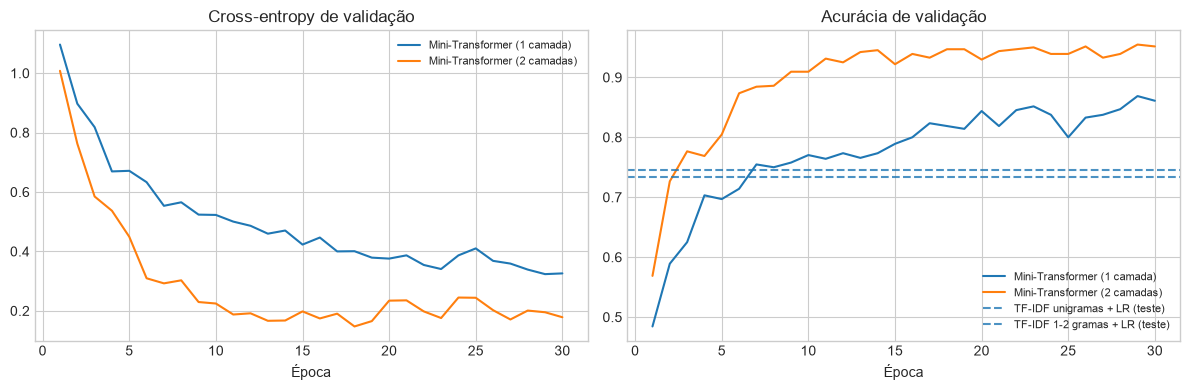

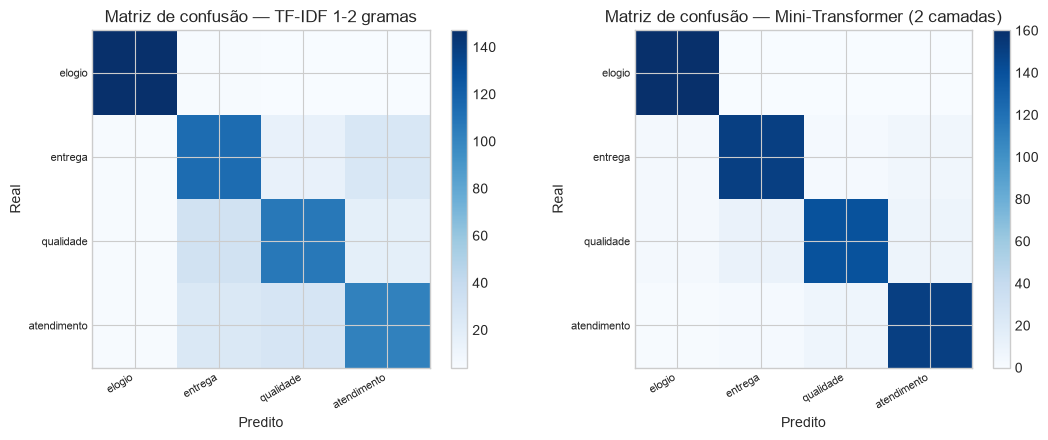

In [6]:
def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


baseline_metrics = {name: evaluate_baseline(ngram, train_df, test_df) for name, ngram in baseline_configs.items()}

transformers, transformer_results, histories = {}, {}, {}
for num_layers in (1, 2):
    torch.manual_seed(SEED)
    model = MiniTransformerClassifier(vocab_size=len(vocab), num_classes=len(label_names),
                                      num_layers=num_layers).to(device)
    history, criterion = train_transformer(model, train_loader, val_loader)
    name = f'Mini-Transformer ({num_layers} camada{"s" if num_layers > 1 else ""})'
    transformers[name] = model
    histories[name] = history
    transformer_results[name] = evaluate_transformer(model, test_loader, criterion)

DEEP = 'Mini-Transformer (2 camadas)'
transformer = transformers[DEEP]
transformer_metrics = transformer_results[DEEP]
history_df = histories[DEEP]

rows = [
    {'modelo': name, 'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'], 'log_loss': m['log_loss'],
     'features_ou_parametros': m['n_features']}
    for name, m in baseline_metrics.items()
]
for name, m in transformer_results.items():
    rows.append({'modelo': name, 'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'],
                 'log_loss': m['log_loss'], 'features_ou_parametros': parameter_count(transformers[name])})
comparison_df = pd.DataFrame(rows)
print(comparison_df.round(4).to_string(index=False))

best_baseline = max(baseline_metrics.values(), key=lambda m: m['accuracy'])
print(f"\nvantagem da atenção (2 camadas) sobre o melhor baseline lexical: "
      f"{100 * (transformer_metrics['accuracy'] - best_baseline['accuracy']):.1f} pontos percentuais")

predictions_by_model = {name: m['y_pred'] for name, m in baseline_metrics.items()}
for name, m in transformer_results.items():
    predictions_by_model[name] = m['y_pred']
by_construction = accuracy_by_construction(test_df, predictions_by_model)
print()
print(by_construction.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    axes[0].plot(history['epoch'], history['val_loss'], label=name)
axes[0].set_title('Cross-entropy de validação')
axes[0].set_xlabel('Época')
axes[0].legend(fontsize=8)

for name, history in histories.items():
    axes[1].plot(history['epoch'], history['val_accuracy'], label=name)
for name, m in baseline_metrics.items():
    axes[1].axhline(m['accuracy'], linestyle='--', alpha=0.8, label=f'{name} (teste)')
axes[1].set_title('Acurácia de validação')
axes[1].set_xlabel('Época')
axes[1].legend(fontsize=8)
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, preds) in zip(axes, [('TF-IDF 1-2 gramas', baseline_metrics['TF-IDF 1-2 gramas + LR']['y_pred']),
                                     (DEEP, transformer_metrics['y_pred'])]):
    cm = confusion_matrix(test_df['label'], preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Matriz de confusão — {title}')
    ax.set_xticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(label_names)))
    ax.set_yticklabels(label_names, fontsize=8)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
Nesta etapa queremos distinguir duas coisas: erros em frases realmente ambíguas e erros que sugerem incapacidade de modelar contexto. A tabela abaixo isola exatamente os casos em que o **baseline lexical erra e a atenção acerta** — se a hipótese estiver correta, eles devem se concentrar em adversativas, negações de escopo e anáforas ordinais.

Há ainda um segundo recorte, mais fino: os casos que **a segunda camada de atenção resolve e a primeira não**. Se eles se concentrarem na negação de escopo, isso confirma o argumento estrutural — negação de escopo é uma composição em dois passos, e uma única rodada de atenção não consegue formá-la.

E um terceiro: os casos em que **os dois erram**. Se forem majoritariamente da construção `ambigua`, a mensagem é que aquele erro residual é do **problema**, não do modelo — nenhuma arquitetura recupera informação que não está no texto.

Também inspecionamos a matriz de atenção de uma frase de negação. A leitura deve ser qualitativa e cautelosa: atenção ajuda no diagnóstico, mas não encerra a explicação do comportamento do modelo.

teste: 640 reviews
  só a atenção acerta : 142
  só o TF-IDF acerta  : 13
  ambos erram         : 28

Casos em que o TF-IDF erra e a atenção acerta:
 construcao                                                                                                                                                text classe_real  pred_tfidf pred_atencao
    ordinal            usei o teclado por um mês e comparando sem exagero, acabamento, no dia a dia, e dessa vez, suporte, até agora, só o segundo decepcionou. atendimento   qualidade  atendimento
    ordinal                                    comparando no fim das contas, assistência, pra mim, e no dia a dia, prazo, de verdade, só o segundo falhou feio.     entrega atendimento      entrega
    negacao                                                                                          não dá pra dizer que garantia de verdade agradou bastante. atendimento      elogio  atendimento
adversativa                     sobre o teclado: no fim das con

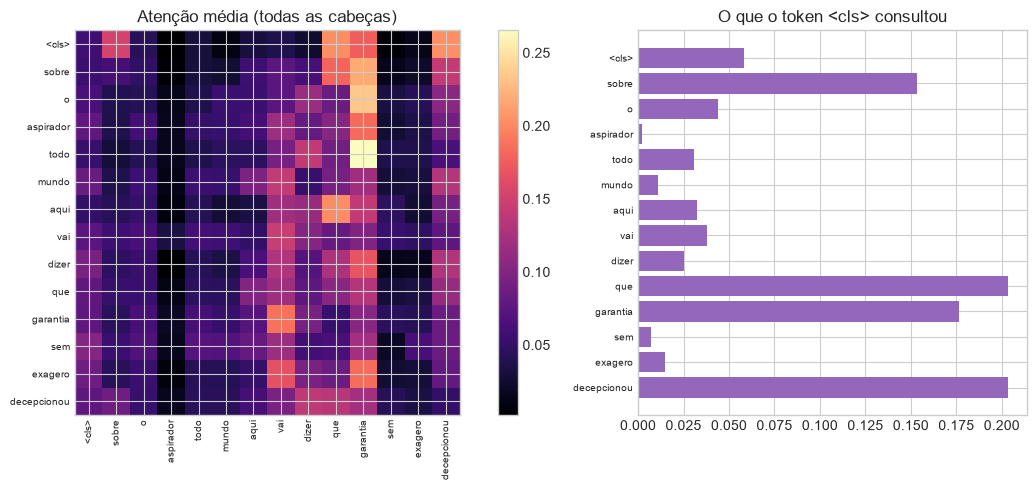

In [7]:
baseline_name = 'TF-IDF 1-2 gramas + LR'
baseline_preds = baseline_metrics[baseline_name]['y_pred']
transformer_preds = transformer_metrics['y_pred']
shallow_preds = transformer_results['Mini-Transformer (1 camada)']['y_pred']
true_labels = test_df['label'].values

only_transformer_right = np.where((baseline_preds != true_labels) & (transformer_preds == true_labels))[0]
both_wrong = np.where((baseline_preds != true_labels) & (transformer_preds != true_labels))[0]
only_baseline_right = np.where((baseline_preds == true_labels) & (transformer_preds != true_labels))[0]

print(f'teste: {len(true_labels)} reviews')
print(f'  só a atenção acerta : {len(only_transformer_right)}')
print(f'  só o TF-IDF acerta  : {len(only_baseline_right)}')
print(f'  ambos erram         : {len(both_wrong)}')

error_table = test_df.iloc[only_transformer_right[:8]].copy()
error_table['classe_real'] = [label_names[i] for i in error_table['label']]
error_table['pred_tfidf'] = [label_names[i] for i in baseline_preds[only_transformer_right[:8]]]
error_table['pred_atencao'] = [label_names[i] for i in transformer_preds[only_transformer_right[:8]]]
error_table = error_table[['construcao', 'text', 'classe_real', 'pred_tfidf', 'pred_atencao']]
with pd.option_context('display.max_colwidth', 130):
    print()
    print('Casos em que o TF-IDF erra e a atenção acerta:')
    print(error_table.to_string(index=False))

depth_gain = np.where((shallow_preds != true_labels) & (transformer_preds == true_labels))[0]
if len(depth_gain):
    depth_table = test_df.iloc[depth_gain[:5]].copy()
    depth_table['classe_real'] = [label_names[i] for i in depth_table['label']]
    depth_table['pred_1_camada'] = [label_names[i] for i in shallow_preds[depth_gain[:5]]]
    with pd.option_context('display.max_colwidth', 130):
        print()
        print(f'Casos que a 2a camada de atenção resolve e a 1a não ({len(depth_gain)} no total, '
              f'{int((test_df["construcao"].values[depth_gain] == "negacao").sum())} deles de negação de escopo):')
        print(depth_table[['construcao', 'text', 'classe_real', 'pred_1_camada']].to_string(index=False))

transformer_errors = np.where(transformer_preds != true_labels)[0]
print(f'\nerros da atenção (2 camadas): {len(transformer_errors)} de {len(true_labels)} '
      f'({len(transformer_errors) / len(true_labels):.1%}); '
      f'{int((test_df["construcao"].values[transformer_errors] == "ambigua").sum())} deles são da construção ambígua')
hard_table = test_df.iloc[transformer_errors[:6]].copy()
hard_table['classe_real'] = [label_names[i] for i in hard_table['label']]
hard_table['pred_atencao'] = [label_names[i] for i in transformer_preds[transformer_errors[:6]]]
with pd.option_context('display.max_colwidth', 130):
    print()
    print('Casos que a atenção também erra (o experimento não saturou):')
    print(hard_table[['construcao', 'text', 'classe_real', 'pred_atencao']].to_string(index=False))

negacao_ok = np.where((test_df['construcao'].values == 'negacao') & (transformer_preds == true_labels))[0]
sample_row = test_df.iloc[negacao_ok[0]]
sample_text = sample_row['text']
sample_tokens, sample_mask = encode(sample_text)
sample_tensor = torch.tensor([sample_tokens], dtype=torch.long).to(device)
sample_mask_tensor = torch.tensor([sample_mask], dtype=torch.bool).to(device)
transformer.eval()
with torch.no_grad():
    logits, attn_weights = transformer(sample_tensor, sample_mask_tensor)
print(f'\nfrase inspecionada ({label_names[sample_row["label"]]}): {sample_text}')
print(f'predição do modelo: {label_names[int(logits.argmax(dim=1))]}')

valid_len = int(sum(sample_mask))
tokens = (['<cls>'] + tokenize(sample_text))[:valid_len]
avg_attn = attn_weights[0].mean(dim=0).cpu().numpy()[:valid_len, :valid_len]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
im = axes[0].imshow(avg_attn, cmap='magma')
axes[0].set_xticks(range(valid_len))
axes[0].set_xticklabels(tokens, rotation=90, fontsize=7)
axes[0].set_yticks(range(valid_len))
axes[0].set_yticklabels(tokens, fontsize=7)
axes[0].set_title('Atenção média (todas as cabeças)')
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].barh(range(valid_len), avg_attn[0], color='tab:purple')
axes[1].set_yticks(range(valid_len))
axes[1].set_yticklabels(tokens, fontsize=7)
axes[1].invert_yaxis()
axes[1].set_title('O que o token <cls> consultou')
plt.tight_layout()

## Fechamento e próximos passos
Desta vez o experimento **consegue distinguir as hipóteses**. Na execução de referência (semente 42):

| modelo | accuracy | macro-F1 | log loss |
|---|---|---|---|
| TF-IDF unigramas + LR | 0.7453 | 0.7420 | 0.6080 |
| TF-IDF 1–2 gramas + LR | 0.7344 | 0.7338 | 0.7220 |
| Mini-Transformer (1 camada) | 0.8531 | 0.8541 | 0.3320 |
| **Mini-Transformer (2 camadas)** | **0.9359** | **0.9354** | **0.2354** |
| *teto de Bayes do corpus* | *0.964* | — | — |

Acurácia por construção:

| construção | TF-IDF uni | TF-IDF 1–2 | atenção 1 camada | atenção 2 camadas |
|---|---|---|---|---|
| direta | 1.000 | 0.994 | 0.988 | 1.000 |
| adversativa | 0.668 | 0.679 | 0.875 | **0.984** |
| negação de escopo | 0.700 | 0.755 | 0.700 | **0.936** |
| anáfora ordinal | 0.661 | 0.605 | 0.911 | **0.952** |
| ambígua | 0.491 | 0.358 | 0.528 | 0.528 |

Três leituras, em ordem de importância:

1. **Nas frases diretas todo mundo empata perto de 100%**, e é nas construções que exigem contexto — adversativa, negação de escopo e anáfora ordinal — que o baseline lexical desaba enquanto a atenção se mantém. São **+19,1 pontos percentuais** no agregado.
2. **Adicionar bigramas não resolve — chega a piorar** (0.7344 contra 0.7453). Como os fillers garantem distância mínima entre o aspecto e o julgamento, a janela de dois tokens não alcança a dependência e só acrescenta features ruidosas.
3. **A profundidade importa, e importa de forma previsível.** A segunda camada resolve 76 casos que a primeira erra, e **32 deles são de negação de escopo** — exatamente a construção que exige compor duas informações em etapas. Uma camada de atenção liga posições; duas camadas compõem relações sobre o resultado da primeira.

E o piso: dos **41 erros** da atenção com 2 camadas, **25 são da construção ambígua** — casos em que o rótulo não está no texto. Descontando-os, o erro "de modelo" cai para 16 em 587, ou 2,7%. Saber separar erro de modelo de erro do problema é parte do trabalho.

Vale registrar por que a versão anterior deste notebook não respondia à pergunta: naquele corpus, cada classe tinha vocabulário próprio e fortemente discriminativo, então TF-IDF e Transformer chegavam ambos a **acurácia 1.000** e a tabela de erros saía vazia. Um experimento saturado não distingue hipóteses — ele só informa que a tarefa era fácil demais para separar os modelos. "100% de acurácia" quase sempre é sinal de alerta sobre o desenho, não de vitória.

O próximo passo do curso sai do desenho arquitetural e entra em um tema transversal a todos os modelos vistos até aqui: otimização, regularização e escolha de hiperparâmetros sob orçamento experimental limitado.